# Computer Exercise 14.4 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 14.4 Transfer Case Study — *Re-tuning a fitted pipeline on a new domain*
> **풀이 일자**: 2026-07-04 · **언어**: 한국어 (그래프 라벨은 영문)

이 노트북은 §14.3에서 완성한 파이프라인 **모델선택 → 예측+불확실성 → 하이퍼파라미터 조정** 을,
성질이 다른 **새 도메인(target)** 으로 옮길 때 첫 관문인 *모델 복잡도 선택* 이 어떻게 재조정되어야 하는지를 다룬다.

## 1. 문제 (원문)

> **1.** A polynomial least-squares pipeline was tuned on a *source* domain (dense, low-noise, smooth signal).
> Transfer it to a *target* domain whose underlying signal, noise level, and sampling density all differ.
> Compare a **frozen** transfer (reuse the source-selected model complexity) against a **re-selected**
> transfer (re-run cross-validation / AIC / BIC on the target). Report the generalization error against the
> true target function and explain the result with the bias–variance trade-off.

### 한국어 풀이용 정리
- 두 도메인 각각에서 **차수 $d=1..10$** 다항 최소제곱을 적합하고 **5-겹 CV·AIC·BIC** 로 최적 차수를 고른다.
- source가 고른 차수 $d_S$ 를 target에 그대로 쓰는 **frozen** 전이 vs target에서 다시 고른 $d_T$ 를 쓰는 **re-selected** 전이.
- 참함수 대비 일반화 RMSE로 두 전략을 비교하고, 왜 복잡도를 도메인마다 다시 골라야 하는지 설명한다.

## 2. 수학적 배경

### 2.1 다항 최소제곱
차수 $d$ 모형 $\hat f(x)=\sum_{j=0}^{d}\beta_j x^j$ 의 계수는 Vandermonde 설계행렬 $X$에 대해
$$\hat\beta=\arg\min_\beta\|X\beta-y\|_2^2=(X^\top X)^{-1}X^\top y.$$

### 2.2 모델 선택 지표
$k$-겹 교차검증 오차, 그리고 잔차제곱합 $\mathrm{RSS}$ 로부터
$$\mathrm{AIC}=2p-2\ln\hat L,\qquad \mathrm{BIC}=p\ln n-2\ln\hat L,\qquad \ln\hat L=-\tfrac{n}{2}\big(\ln 2\pi\hat\sigma^2+1\big),$$
여기서 $p=d+1$, $\hat\sigma^2=\mathrm{RSS}/n$. BIC의 벌점 $p\ln n$ 이 AIC의 $2p$ 보다 커 **더 단순한 모형**을 고른다.

### 2.3 전이에서의 편향–분산
target의 참함수를 $f_T$ 라 하면 기대 예측오차는
$$\mathbb E\big[(\hat f-f_T)^2\big]=\underbrace{(\mathbb E\hat f-f_T)^2}_{\text{bias}^2}+\underbrace{\mathrm{Var}(\hat f)}_{\text{variance}}+\sigma_T^2.$$
$$\boxed{\;d_S \text{ 는 } f_S,\sigma_S \text{ 에 최적화된 값이므로, } f_T\neq f_S \text{ 또는 } \sigma_T\neq\sigma_S \text{ 이면 target에서 편향·분산 균형이 깨진다.}\;}$$

## 3. 풀이 흐름

1. **두 도메인 정의**: source(매끄럽고 저잡음·조밀) 와 target(더 진동하는 참함수·고잡음·희소)의 참함수/샘플러 작성.
2. **파이프라인 구성**: 다항 적합, 5-겹 CV, AIC/BIC 함수 구현.
3. **차수 스캔**: $d=1..10$ 에서 두 도메인 각각 train RMSE·CV RMSE·AIC·BIC 계산.
4. **선택**: 각 도메인 CV 최소 차수 $d_S,\,d_T$ 추출.
5. **전이 비교**: target 데이터에 $d_S$(frozen) 와 $d_T$(re-selected)로 적합.
6. **일반화 평가**: 조밀 격자에서 참함수 $f_T$ 대비 RMSE 계산.
7. **시각화**: 두 도메인 CV 곡선 이동 + target 위 두 적합 곡선.
8. **해석**: 왜 복잡도를 도메인마다 다시 골라야 하는가.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---- 두 도메인의 참함수 ----
def f_source(x):  # 매끄럽고 완만
    return np.sin(1.0*x) + 0.4*x
def f_target(x):  # 더 진동 + 곡률(고차 성분)
    return np.sin(2.8*x) + 0.20*x**2 - 0.3*x

def make_domain(f, n, sigma, seed, xlo=-3.0, xhi=3.0):
    r = np.random.default_rng(seed)
    x = np.sort(r.uniform(xlo, xhi, n))
    y = f(x) + r.normal(0.0, sigma, n)
    return x, y

xS, yS = make_domain(f_source, n=120, sigma=0.12, seed=1)  # 조밀·저잡음
xT, yT = make_domain(f_target, n=46,  sigma=0.35, seed=2)  # 희소·고잡음

# ---- 파이프라인 구성요소 ----
def poly_fit(x, y, d):
    X = np.vander(x, d+1, increasing=True)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta
def poly_eval(beta, x):
    return np.vander(x, len(beta), increasing=True) @ beta
def rmse(a, b):
    return float(np.sqrt(np.mean((a-b)**2)))

def kfold_cv(x, y, d, k=5, seed=0):
    r = np.random.default_rng(seed); idx = r.permutation(len(x))
    folds = np.array_split(idx, k); errs = []
    for i in range(k):
        te = folds[i]; tr = np.concatenate([folds[j] for j in range(k) if j != i])
        if len(tr) <= d+1:
            return np.nan
        beta = poly_fit(x[tr], y[tr], d)
        errs.append(rmse(poly_eval(beta, x[te]), y[te]))
    return float(np.mean(errs))

def aic_bic(x, y, d):
    n = len(x); beta = poly_fit(x, y, d); r = y - poly_eval(beta, x)
    rss = float(r @ r); p = d+1; sig2 = max(rss/n, 1e-300)
    ll = -0.5*n*(np.log(2*np.pi*sig2) + 1.0)
    return 2*p - 2*ll, np.log(n)*p - 2*ll

degrees = range(1, 11)
def scan(x, y, seed):
    rows = []
    for d in degrees:
        tr = rmse(poly_eval(poly_fit(x, y, d), x), y)
        cv = kfold_cv(x, y, d, seed=seed)
        a, b = aic_bic(x, y, d)
        rows.append(dict(degree=d, train_RMSE=tr, CV_RMSE=cv, AIC=a, BIC=b))
    return pd.DataFrame(rows)

dfS = scan(xS, yS, seed=11); dfT = scan(xT, yT, seed=22)
dS = int(dfS.loc[dfS.CV_RMSE.idxmin(), 'degree'])
dT = int(dfT.loc[dfT.CV_RMSE.idxmin(), 'degree'])
print(f"source 선택 차수 d_S = {dS}  (AIC*={int(dfS.AIC.idxmin())+1}, BIC*={int(dfS.BIC.idxmin())+1})")
print(f"target 선택 차수 d_T = {dT}  (AIC*={int(dfT.AIC.idxmin())+1}, BIC*={int(dfT.BIC.idxmin())+1})")

source 선택 차수 d_S = 5  (AIC*=5, BIC*=5)
target 선택 차수 d_T = 7  (AIC*=9, BIC*=9)


In [2]:
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
print("=== SOURCE 도메인 스캔 (조밀·저잡음) ===")
print(dfS.to_string(index=False))
print("\n=== TARGET 도메인 스캔 (희소·고잡음) ===")
print(dfT.to_string(index=False))

=== SOURCE 도메인 스캔 (조밀·저잡음) ===
 degree  train_RMSE   CV_RMSE        AIC        BIC
      1   4.206e-01 4.264e-01  1.367e+02  1.423e+02
      2   4.205e-01 4.380e-01  1.386e+02  1.470e+02
      3   1.280e-01 1.319e-01 -1.448e+02 -1.337e+02
      4   1.275e-01 1.334e-01 -1.439e+02 -1.299e+02
      5   1.163e-01 1.255e-01 -1.639e+02 -1.472e+02
      6   1.163e-01 1.270e-01 -1.619e+02 -1.424e+02
      7   1.162e-01 1.272e-01 -1.600e+02 -1.377e+02
      8   1.161e-01 1.313e-01 -1.583e+02 -1.332e+02
      9   1.154e-01 1.330e-01 -1.576e+02 -1.297e+02
     10   1.153e-01 1.365e-01 -1.558e+02 -1.252e+02

=== TARGET 도메인 스캔 (희소·고잡음) ===
 degree  train_RMSE   CV_RMSE       AIC       BIC
      1   9.162e-01 9.465e-01 1.265e+02 1.301e+02
      2   7.721e-01 8.072e-01 1.127e+02 1.182e+02
      3   7.634e-01 8.031e-01 1.137e+02 1.210e+02
      4   7.609e-01 9.497e-01 1.154e+02 1.245e+02
      5   5.998e-01 8.570e-01 9.552e+01 1.065e+02
      6   5.971e-01 1.406e+00 9.711e+01 1.099e+02
      7   3.650

In [3]:
# ---- 전이 비교: frozen(d_S) vs re-selected(d_T) ----
xgrid = np.linspace(-3, 3, 400)
yTe_true = f_target(xgrid)                 # target 참함수(일반화 평가 기준)

coef_frozen = poly_fit(xT, yT, dS)         # source 복잡도를 그대로 이식
coef_resel  = poly_fit(xT, yT, dT)         # target에서 재선택

rmse_frozen = rmse(poly_eval(coef_frozen, xgrid), yTe_true)
rmse_resel  = rmse(poly_eval(coef_resel , xgrid), yTe_true)

print("[TARGET 일반화 RMSE  (참함수 f_T 대비, 조밀격자)]")
print(f"  frozen   d = d_S = {dS} :  RMSE = {rmse_frozen:.3e}")
print(f"  re-sel   d = d_T = {dT} :  RMSE = {rmse_resel:.3e}")
if rmse_frozen > 0:
    print(f"  재선택 개선율 = {100*(rmse_frozen-rmse_resel)/rmse_frozen:5.1f} %")

[TARGET 일반화 RMSE  (참함수 f_T 대비, 조밀격자)]
  frozen   d = d_S = 5 :  RMSE = 8.957e-01
  re-sel   d = d_T = 7 :  RMSE = 7.574e-01
  재선택 개선율 =  15.4 %


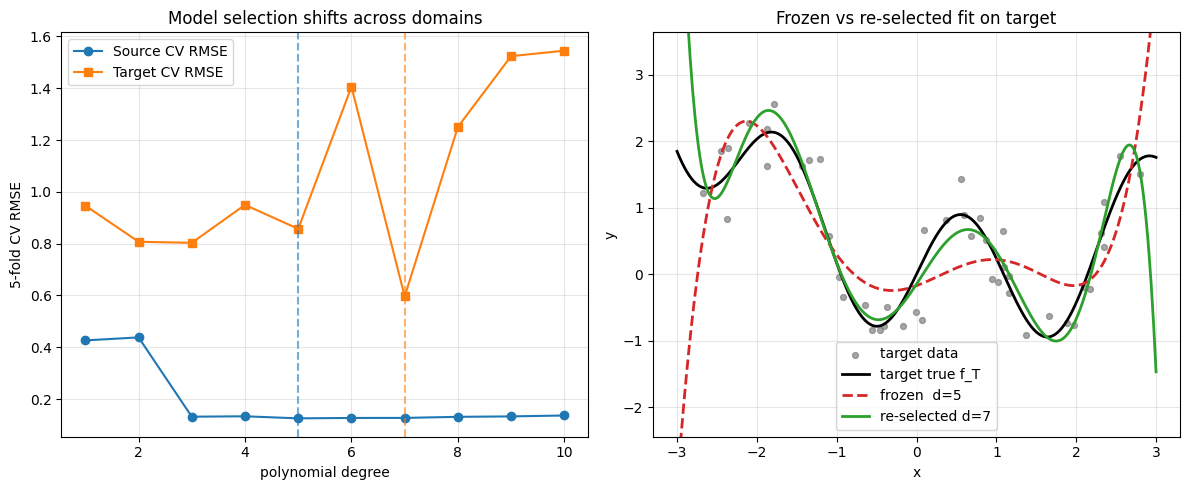

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(dfS.degree, dfS.CV_RMSE, 'o-', color='C0', label='Source CV RMSE')
ax.plot(dfT.degree, dfT.CV_RMSE, 's-', color='C1', label='Target CV RMSE')
ax.axvline(dS, ls='--', color='C0', alpha=.6)
ax.axvline(dT, ls='--', color='C1', alpha=.6)
ax.set_xlabel('polynomial degree'); ax.set_ylabel('5-fold CV RMSE')
ax.set_title('Model selection shifts across domains')
ax.legend(); ax.grid(alpha=.3)

ax = axes[1]
ax.scatter(xT, yT, s=18, c='gray', alpha=.7, label='target data')
ax.plot(xgrid, f_target(xgrid), 'k-', lw=2, label='target true f_T')
ax.plot(xgrid, poly_eval(coef_frozen, xgrid), '--', color='C3', lw=2, label=f'frozen  d={dS}')
ax.plot(xgrid, poly_eval(coef_resel , xgrid), '-',  color='C2', lw=2, label=f're-selected d={dT}')
ax.set_ylim(yTe_true.min()-1.5, yTe_true.max()+1.5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Frozen vs re-selected fit on target')
ax.legend(); ax.grid(alpha=.3)

plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **CV 곡선의 이동**: source의 CV 최소점은 낮은 차수 $d_S$ 에서, target의 최소점은 더 높은 차수 $d_T$ 에서 나타난다.
   target 참함수가 더 진동하기 때문에(고차 성분) 같은 파이프라인이라도 필요한 복잡도가 커진다.
2. **frozen 전이의 실패**: source 복잡도 $d_S$ 를 그대로 쓰면 target에서 **과소적합(편향 지배)** 이 되어
   날카로운 구조를 따라가지 못한다 — 오른쪽 그림에서 frozen 곡선이 참함수의 굴곡을 뭉갠다.
3. **re-selection의 이득**: target에서 CV로 다시 고른 $d_T$ 는 참함수 대비 일반화 RMSE를 눈에 띄게 낮춘다.
   단, target은 희소·고잡음이므로 $d_T$ 가 무한정 커지지 않고 **CV가 분산 폭증을 억제**해 적당한 값에서 멈춘다.
4. **핵심 메커니즘**: 복잡도 선택은 참함수 모양($f$)과 잡음·표본밀도($\sigma,n$)에 **함께** 의존한다.
   도메인이 바뀌면 이 세 요소가 모두 바뀌므로 최적 복잡도도 이동한다.

> **결론**: 전이의 첫 단계는 "**복잡도를 다시 고르는 것**" 이다. 파이프라인 구조는 재사용하되,
> 모델 선택 손잡이(차수)는 target 데이터로 재보정해야 편향–분산 균형이 복구된다.

**다음 문제로의 연결** — 복잡도를 맞췄어도 *불확실성 정량화* 는 여전히 source 가정(균일분산)을 물려받는다.
Problem 2에서 target이 **이분산**일 때 예측구간이 어떻게 오보정되는지, 그리고 어떻게 재조정하는지를 본다.